In [3]:
import xarray as xr
import numpy as np
from pathlib import Path
import gsw
from xarray import open_mfdataset, open_dataset
from matplotlib import pyplot as plt



# Utilities 
def find_grid_files(grid_type, years, nest, model, delta_t, folder = 'output'): 
    experiment_path = Path('/gxfs_work/geomar/smomw355/model_data/ocean-only/')
    nest_part = '1_' if nest else '' 

    if len(grid_type) < 2:
        grid_type = f'grid_{grid_type}'

    grid_files = (experiment_path / model / 'nemo' / folder).glob(f'{nest_part}{model}_{delta_t}_*_*_{grid_type}.nc')
    grid_files = list(grid_files)
    
    result_files = []
    for file in grid_files:
        start_year = int(str(file).split('/')[-1].split('_')[- (3 + grid_type.count('_'))][:4])
        
        if (years[0] is None or start_year >= years[0]) and \
           (years[1] is None or start_year < years[1]):
            result_files.append(file)
    
    return sorted(result_files)

def load_dataset_from_grid_type(grid_type, years, nest, model, delta_t, chunks = {"time_counter" : 2,"y": 2, "x": None}, **kwargs):
    files_list = find_grid_files(grid_type, years, nest, model, delta_t, **kwargs)
    grid = open_mfdataset(
        files_list, # type: ignore
        chunks= chunks,
        combine='by_coords'
    )
    return grid

def load_masks(nest, model):

    if str.startswith(model, 'VIKING20X.L46-KFS003'):
        # All the mask for the long runs VIKING20X.L46-KFS003-2nd, ... are placed in the original experiment
        model = 'VIKING20X.L46-KFS003' 
    
    nest_part = '1_' if nest else ''
    
    mask_mesh = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}mesh_mask.nc',
        decode_cf=False,
        chunks={'y': 100, 'x':100, 'z': -1},
    )

    if model == 'VIKING20X.L46-KFS003' and not nest:
        nest_part = 'ori_'

    mask_glo = open_dataset(
        f'/gxfs_work/geomar/smomw355/model_data/ocean-only/{model}/nemo/suppl/{nest_part}new_maskglo.nc',
        decode_cf=False,
        chunks={'Y':100, 'X':100, 'z': -1}
    )

    mask_mesh = mask_mesh.squeeze()
    mask_glo = mask_glo.rename({'X':'x', 'Y':'y'}).squeeze() # Rename coordinates to have the same name as the data file
    
    return mask_mesh, mask_glo



In [14]:

import numpy as np
import xarray as xr
from pathlib import Path


cycle_number = 6
smoothing_days = 90
time_smooth = f'{smoothing_days}D'

dask_url = 'tcp://10.0.4.100:8786'

if cycle_number == 1:
    suffix = '1st_7024' 
    model = 'VIKING20X.L46-KFS003'
    model_years_selector = (1970, 2024)
elif cycle_number == 2:
    suffix = '2nd_5824'
    model = 'VIKING20X.L46-KFS003-2nd'
    model_years_selector = (1958, 2024)
elif cycle_number == 3:
    suffix = '3rd_5824'
    model = 'VIKING20X.L46-KFS003-3rd'
    model_years_selector = (1958, 2024)
elif cycle_number == 4:
    suffix = '4th_5824'
    model = 'VIKING20X.L46-KFS003-4th'
    model_years_selector = (1958, 2024)
elif cycle_number == 5:
    suffix = '5th_5824'
    model = 'VIKING20X.L46-KFS003-5th'
    model_years_selector = (1958, 2024)
elif cycle_number == 6:
    suffix = '6th_5824'
    model = 'VIKING20X.L46-KFS003-6th'
    model_years_selector = (1958, 2024)
else:
    assert False, 'Cycle number not recognized'


dataset_path = Path(f'../rapid-geostrophic-reconstruction/datasets/smoothing_{smoothing_days}_days/argo_after_2012/paperdraft/')


In [6]:
from dask.distributed import Client
from dask_jobqueue import SLURMCluster
import os

client = Client(dask_url)
client

<Client: 'tcp://10.0.4.100:8786' processes=390 threads=390, memory=4.26 TiB>

In [8]:




psi = load_dataset_from_grid_type('psi', model_years_selector, True, model, '1d', chunks = {'time_counter':None, 'x': None, 'y': None}, folder = 'derived')
        
florida_strait = (psi.sobarstf.isel(x = 391, y = 1278) - psi.sobarstf.isel(x = 367, y = 1278))

In [9]:
florida_strait = florida_strait.compute()
florida_strait.to_netcdf(f'../rapid-geostrophic-reconstruction/datasets/florida_current/florida_current_KFS003-{suffix}.nc')


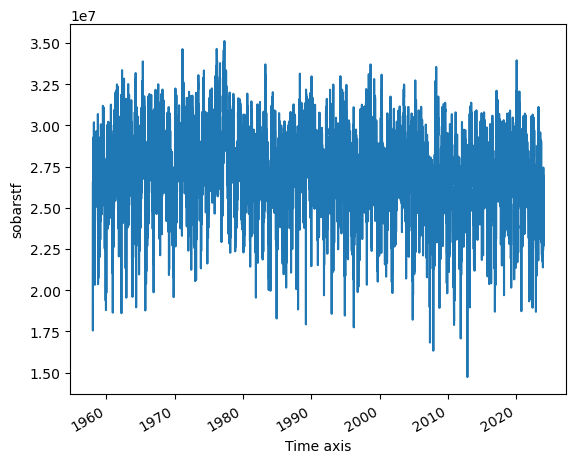

In [10]:
florida_strait.plot()